# Assignment IV: Optimization with Parallelization

## Task 1.1

We have to pad the result arrays to the same length for the mean to work. Then `starmap` is used instead of `map` to not pass any arguments.

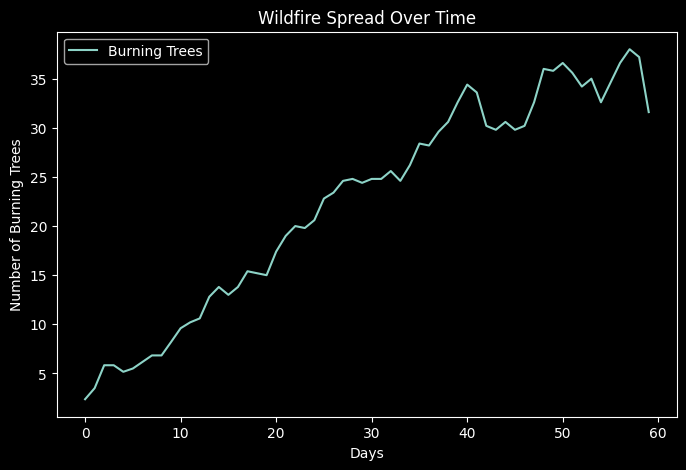

In [1]:
import multiprocessing
import numpy as np
import matplotlib.pyplot as plt

from wildfire import simulate_wildfire, DAYS


def mp_wildfire(p):
    with multiprocessing.Pool(p) as pool:
        results = pool.starmap(simulate_wildfire, [() for _ in range(p)])
        results = [r + [np.nan] * (DAYS - len(r)) for r in results]
        return np.nanmean(results, axis=0)


avg = mp_wildfire(8)
plt.figure(figsize=(8, 5))
plt.plot(range(len(avg)), avg, label="Burning Trees")
plt.xlabel("Days")
plt.ylabel("Number of Burning Trees")
plt.title("Wildfire Spread Over Time")
plt.legend()
plt.show()

## Task 1.2

http://127.0.0.1:8787/status


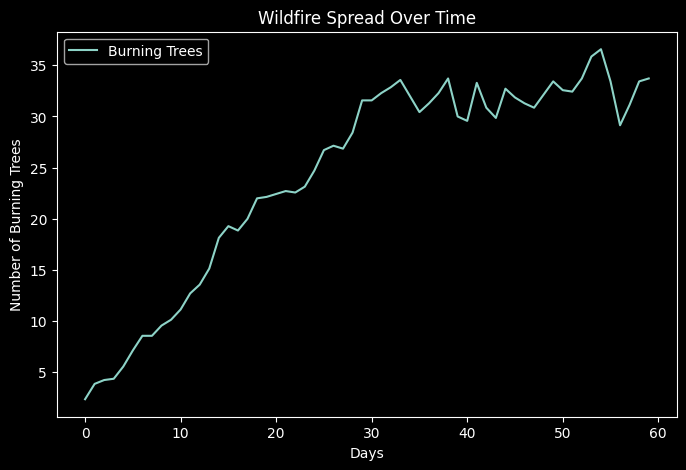

In [2]:
import dask
import numpy as np
import dask.array as da
import matplotlib.pyplot as plt
from dask.distributed import Client, LocalCluster
from wildfire import simulate_wildfire, DAYS


def dask_wildfire_inner(p, chunk_dim):
    @dask.delayed
    def padded():
        arr = np.array(simulate_wildfire(), dtype=float)
        return np.pad(arr, (0, DAYS - len(arr)), 'constant', constant_values=np.nan)

    darrs = [da.from_delayed(padded(), shape=(DAYS,), dtype=float) for _ in range(p)]
    stacked = da.stack(darrs, axis=0)
    stacked = stacked.rechunk(chunk_dim)
    mean = da.nanmean(stacked, axis=0)
    return mean.compute()


def dask_wildfire(p, chunk_dim):
    cluster = LocalCluster(n_workers=p)
    client = Client(cluster)
    print(client.dashboard_link)

    avg = dask_wildfire_inner(p, chunk_dim)

    client.close()
    cluster.close()
    return avg


avg = dask_wildfire(8, (1, DAYS))
plt.figure(figsize=(8, 5))
plt.plot(range(len(avg)), avg, label="Burning Trees")
plt.xlabel("Days")
plt.ylabel("Number of Burning Trees")
plt.title("Wildfire Spread Over Time")
plt.legend()
plt.show()

## Task 1.3

In [3]:
import timeit
import numpy as np


def benchmark(f, args):
    timer = timeit.Timer(lambda: f(*args))
    ts = timer.repeat(repeat=30, number=1)
    return np.mean(ts)

http://127.0.0.1:8787/status
[2026-03-04 20:48:10.644004] Benchmarking (Serial)
[2026-03-04 20:49:33.744836] Benchmarking (Mp):	 1


/tmp/ipykernel_33898/3811179251.py:12: RuntimeWarning: Mean of empty slice
  return np.nanmean(results, axis=0)


[2026-03-04 20:51:08.871882] Benchmarking (Dask):	 1
[2026-03-04 20:52:46.115184] Benchmarking (Mp):	 2


/tmp/ipykernel_33898/3811179251.py:12: RuntimeWarning: Mean of empty slice
  return np.nanmean(results, axis=0)


[2026-03-04 20:54:28.183022] Benchmarking (Dask):	 2
[2026-03-04 20:56:16.721165] Benchmarking (Mp):	 4
[2026-03-04 20:58:12.162402] Benchmarking (Dask):	 4
[2026-03-04 21:00:08.165700] Benchmarking (Mp):	 8
[2026-03-04 21:02:07.890454] Benchmarking (Dask):	 8
[2026-03-04 21:04:18.140987] done!


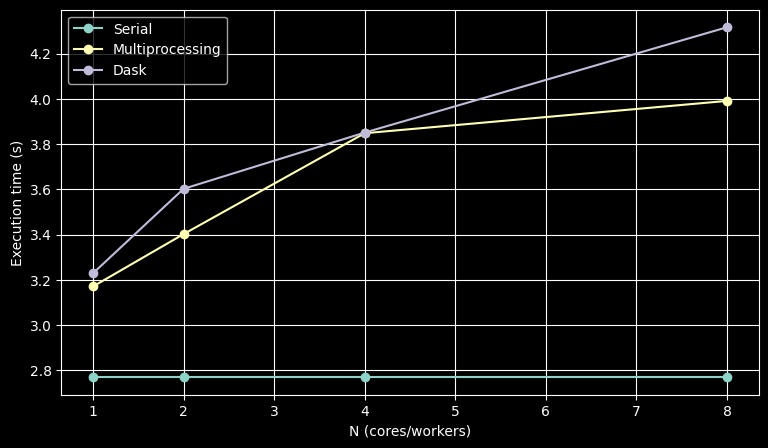

In [4]:
import matplotlib.pyplot as plt
from datetime import datetime
from wildfire import simulate_wildfire, DAYS

cores = [1, 2, 4, 8]

simulate_wildfire()
mp_wildfire(8)
dask_wildfire(8, (1, DAYS))

print(f"[{datetime.now()}]", "Benchmarking (Serial)")
serial = [benchmark(simulate_wildfire, ())] * len(cores)

mp, d = [], []
for c in cores:
    print(f"[{datetime.now()}]", "Benchmarking (Mp):\t", c)
    mp.append(benchmark(mp_wildfire, (c,)))

    print(f"[{datetime.now()}]", "Benchmarking (Dask):\t", c)
    cluster = LocalCluster(n_workers=c, dashboard_address=":0")
    client = Client(cluster)
    d.append(benchmark(dask_wildfire_inner, (c, (1, DAYS))))
    client.close()
    cluster.close()
print(f"[{datetime.now()}]", "done!")

plt.figure(figsize=(9, 5))
plt.plot(cores, serial, marker='o', label="Serial")
plt.plot(cores, mp, marker='o', label="Multiprocessing")
plt.plot(cores, d, marker='o', label="Dask")

plt.legend()
plt.xlabel("N (cores/workers)")
plt.ylabel("Execution time (s)")
plt.grid(True)
plt.show()

When analyzing the plot it is important to keep in mind that the parallelized versions run multiple simulations so the execution time is dominated by the slowest one + synchronization overhead, and that the simulation uses random values which may add fluctuations or artifacts.

 Now to answer which version is the fastest. For all the cores we see that the native version would be the fastest, however it only runs 1 simulation, if we wanted to match the throughput of the parallelized version we would have to run the native version back to back, which for just 2 simulations would take around 5 seconds making it the overall slowest. Therefore, the `MP` is the fastet if we need more than 2 simulations, which is faster than `Dask` liekly due to the task being small and the scheduler overad intedocued by `Dask`.

`Dask` seems to scale well with the number of workers, the overhead of more workers + synchronisation seem to be either linear or logarithmic, however the simulations run here are independent of each other so this is not indicative of general `Dask` performance.

http://127.0.0.1:8787/status
[2026-03-04 20:05:52.801215] Benchmarking (H):	 (4, 1)
[2026-03-04 20:07:53.095992] Benchmarking (H):	 (4, 10)
[2026-03-04 20:09:45.957617] Benchmarking (H):	 (4, 20)
[2026-03-04 20:11:38.417522] Benchmarking (H):	 (4, 30)
[2026-03-04 20:13:30.197592] Benchmarking (H):	 (4, 40)
[2026-03-04 20:15:21.623571] Benchmarking (H):	 (4, 50)
[2026-03-04 20:17:14.033213] Benchmarking (H):	 (4, 60)
[2026-03-04 20:19:04.565476] Benchmarking (V):	 (1, 30)
[2026-03-04 20:20:56.706077] Benchmarking (V):	 (2, 30)
[2026-03-04 20:22:49.167462] Benchmarking (V):	 (4, 30)
[2026-03-04 20:24:42.008155] Benchmarking (V):	 (8, 30)
[2026-03-04 20:26:35.272159] done!


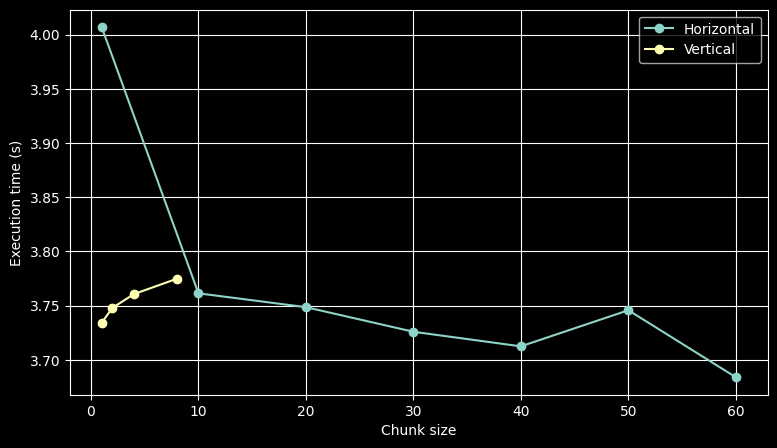

In [4]:
import matplotlib.pyplot as plt
from datetime import datetime
from wildfire import simulate_wildfire, DAYS

cores = [1, 2, 4, 8]
days = [1 , 10, 20, 30, 40, 50, 60]
chunks_h = [(4, i) for i in days]
chunks_v = [(i, DAYS // 2) for i in cores]

dask_wildfire(8, (1, DAYS))

ch, cv = [], []
cluster = LocalCluster(n_workers=4, dashboard_address=":0")
client = Client(cluster)
for h in chunks_h:
    print(f"[{datetime.now()}]", "Benchmarking (H):\t", h)
    ch.append(benchmark(dask_wildfire_inner, (4, h)))
for v in chunks_v:
    print(f"[{datetime.now()}]", "Benchmarking (V):\t", v)
    cv.append(benchmark(dask_wildfire_inner, (4, v)))
print(f"[{datetime.now()}]", "done!")
client.close()
cluster.close()

plt.figure(figsize=(9, 5))
plt.plot(days, ch, marker='o', label="Horizontal")
plt.plot(cores, cv, marker='o', label="Vertical")

plt.legend()
plt.xlabel("Chunk size")
plt.ylabel("Execution time (s)")
plt.grid(True)
plt.show()

It seems that horizontal chunking (chunking data from a single simulation) has the most significant effect, but only for chunks with width 1-10 after that the gains fall off, but 60 (the length of the entire simulation) still being the best. It seems chunking to narrow (1-10) results in many delays between workers which drastically slows down the simulation. Chunking vertically (multiple simulations per chunk) seems to be marginally detrimental, the `Dask` seems to prefer granularity here, which with 4 workers results in 1 simulation per worker. So in conclusion the most likely best chunk size for this problem is `(1, DAYS)` which is expected since the problem is a bit too small for `Dask`.

## Task 1.4